# Importing Our Data

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atulyakumar98/gundetection")

print("Path to dataset files:", path)

100%|██████████| 250M/250M [00:07<00:00, 37.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/atulyakumar98/gundetection/versions/2


In [3]:
import os

In [4]:
os.listdir(path)

['1690.txt',
 '58.txt',
 '372.txt',
 '1531.jpg',
 '2532.txt',
 '1216.jpg',
 '1911.jpg',
 '762.jpg',
 '2518.jpg',
 '2317.txt',
 '1858.txt',
 '1797.txt',
 '2779.txt',
 '1219.txt',
 '1474.jpg',
 '152.txt',
 '599.jpg',
 '373.jpg',
 '1661.txt',
 '649.jpg',
 '2078.txt',
 '949.jpg',
 '1466.txt',
 '1475.txt',
 '2052.txt',
 '2063.jpg',
 '2351.jpg',
 '1076.txt',
 '1400.jpg',
 '2838.txt',
 '2886.jpg',
 '1099.jpg',
 '64.jpg',
 '2635.txt',
 '195.jpg',
 '976.txt',
 '2996.txt',
 '2710.jpg',
 '2232.jpg',
 '1837.txt',
 '2470.txt',
 '1166.jpg',
 '2056.jpg',
 '889.jpg',
 '1436.txt',
 '1693.txt',
 '298.jpg',
 '2983.txt',
 '2151.jpg',
 '924.jpg',
 '2681.jpg',
 '2702.jpg',
 '485.jpg',
 '2401.txt',
 '1786.txt',
 '359.jpg',
 '1332.txt',
 '2900.jpg',
 '1927.txt',
 '1408.txt',
 '982.jpg',
 '2354.txt',
 '149.jpg',
 '1814.txt',
 '867.txt',
 '2820.txt',
 '894.jpg',
 '2659.txt',
 '1659.txt',
 '748.jpg',
 '393.jpg',
 '2053.txt',
 '1101.txt',
 '1558.txt',
 '108.txt',
 '2860.jpg',
 '2376.txt',
 '736.jpg',
 '69.txt',
 

In [5]:
print("Number of files:", len(os.listdir(path)))

print("\nFirst 30 files:")
for file in os.listdir(path)[:30]:
    print(file)

Number of files: 6000

First 30 files:
1690.txt
58.txt
372.txt
1531.jpg
2532.txt
1216.jpg
1911.jpg
762.jpg
2518.jpg
2317.txt
1858.txt
1797.txt
2779.txt
1219.txt
1474.jpg
152.txt
599.jpg
373.jpg
1661.txt
649.jpg
2078.txt
949.jpg
1466.txt
1475.txt
2052.txt
2063.jpg
2351.jpg
1076.txt
1400.jpg
2838.txt


In [6]:
from collections import Counter

files = os.listdir(path)

extensions = Counter(
    os.path.splitext(file)[1].lower()
    for file in files
)

print(extensions)

Counter({'.txt': 3000, '.jpg': 3000})


***Lets we counting images***

In [7]:
image_extensions = (".jpg", ".jpeg", ".png")

image_files = [
    file for file in os.listdir(path)
    if file.lower().endswith(image_extensions)
]

print("Total images:", len(image_files))

Total images: 3000


In [8]:
print(image_files[:20])

['1531.jpg', '1216.jpg', '1911.jpg', '762.jpg', '2518.jpg', '1474.jpg', '599.jpg', '373.jpg', '649.jpg', '949.jpg', '2063.jpg', '2351.jpg', '1400.jpg', '2886.jpg', '1099.jpg', '64.jpg', '195.jpg', '2710.jpg', '2232.jpg', '1166.jpg']


***Lets we counts label files and looking inside***

In [9]:
label_files = [
    file for file in os.listdir(path)
    if file.lower().endswith(".txt")
]

print("Total label files:", len(label_files))
print(label_files[:20])

Total label files: 3000
['1690.txt', '58.txt', '372.txt', '2532.txt', '2317.txt', '1858.txt', '1797.txt', '2779.txt', '1219.txt', '152.txt', '1661.txt', '2078.txt', '1466.txt', '1475.txt', '2052.txt', '1076.txt', '2838.txt', '2635.txt', '976.txt', '2996.txt']


In [10]:
sample_label = label_files[0]

with open(os.path.join(path, sample_label), "r") as f:
    content = f.read()

print("File:", sample_label)
print(content)

File: 1690.txt
1 0.49062500000000003 0.49166666666666664 0.95625 0.9666666666666667



***Showing an image***

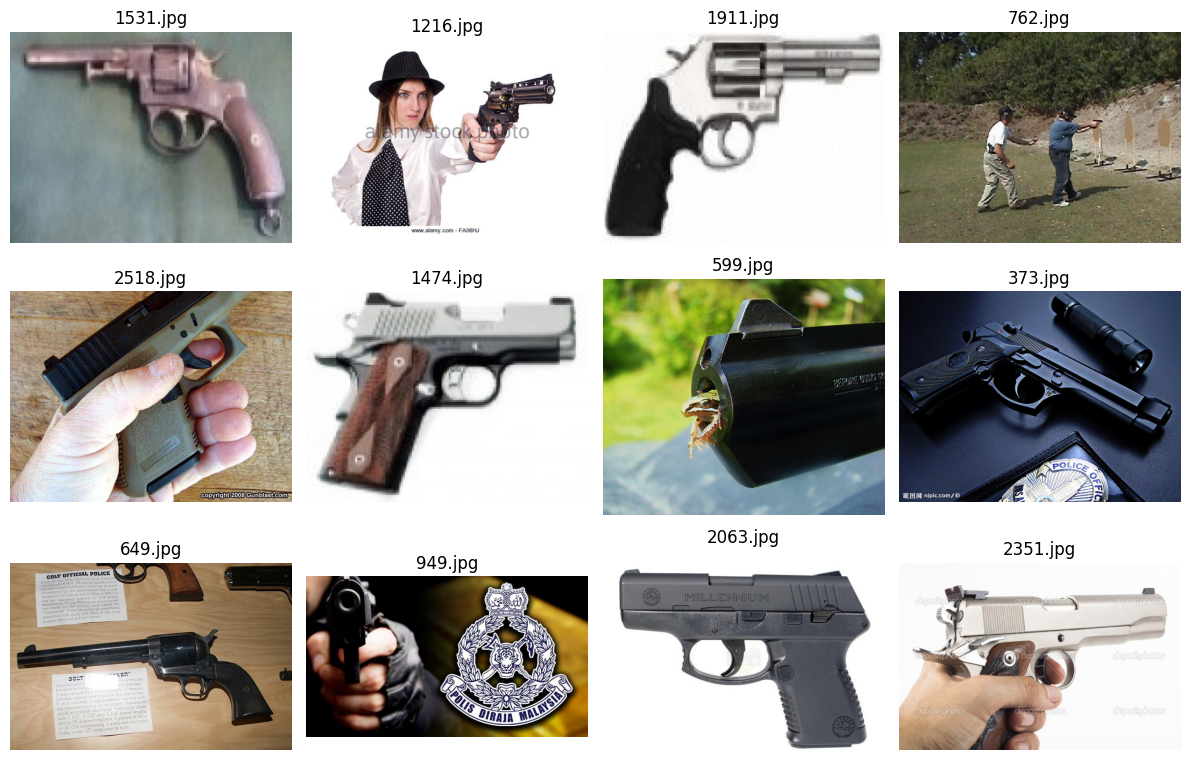

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i, file in enumerate(image_files[:12]):

    image_path = os.path.join(path, file)
    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
txt_files = [
    file for file in files
    if file.lower().endswith(".txt")
]

print("Total TXT files:", len(txt_files))
print("\nFirst 10 TXT files:")

for file in txt_files[:10]:
    print(file)

Total TXT files: 3000

First 10 TXT files:
1690.txt
58.txt
372.txt
2532.txt
2317.txt
1858.txt
1797.txt
2779.txt
1219.txt
152.txt


In [13]:
print("Number of images:", len(image_files))

Number of images: 3000


In [14]:
print("Number of TXT files:", len(txt_files))

Number of TXT files: 3000


In [15]:
sample_txt = txt_files[0]

with open(os.path.join(path, sample_txt), "r") as f:
    print(f.read())

1 0.49062500000000003 0.49166666666666664 0.95625 0.9666666666666667



In [16]:
from collections import Counter

class_ids = []

for file in txt_files:
    with open(os.path.join(path, file), "r") as f:
        for line in f:
            parts = line.strip().split()

            if parts:
                class_ids.append(parts[0])

print(Counter(class_ids))

Counter({'1': 3464})


In [17]:
empty_txt_files = []

for file in txt_files:
    with open(os.path.join(path, file), "r") as f:
        content = f.read().strip()

    if not content:
        empty_txt_files.append(file)

print("Images with empty annotations:", len(empty_txt_files))
print(empty_txt_files[:20])

Images with empty annotations: 0
[]


In [18]:
import os
import shutil

classification_path = "/content/classification_dataset"

gun_path = os.path.join(classification_path, "Gun")
no_gun_path = os.path.join(classification_path, "No_Gun")

os.makedirs(gun_path, exist_ok=True)
os.makedirs(no_gun_path, exist_ok=True)

print("Folders created:")
print(gun_path)
print(no_gun_path)

Folders created:
/content/classification_dataset/Gun
/content/classification_dataset/No_Gun


In [19]:
for file in image_files:
    source = os.path.join(path, file)
    destination = os.path.join(gun_path, file)

    shutil.copy2(source, destination)

print("Gun images copied:", len(os.listdir(gun_path)))

Gun images copied: 3000


***Lets we select Gun 1000 and No-gun 1000 Images***

In [20]:
import random
import shutil
import os

gun_files = os.listdir(gun_path)

random.seed(42)
selected_gun = random.sample(gun_files, 1000)

# Optional: create a smaller Gun folder
gun_1000_path = "/content/classification_dataset/Gun_1000"
os.makedirs(gun_1000_path, exist_ok=True)

for file in selected_gun:
    shutil.copy2(
        os.path.join(gun_path, file),
        os.path.join(gun_1000_path, file)
    )

print("Gun images:", len(os.listdir(gun_1000_path)))

Gun images: 1000


***We are downloading the no-gun Dataset for training,because our all data is of Gun Images***

In [1]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train:", x_train.shape)
print("Test:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1251s 7us/step
Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [21]:
from PIL import Image

for i in range(1000):
    image = Image.fromarray(x_train[i])
    image.save(os.path.join(no_gun_path, f"no_gun_{i}.jpg"))

print("No_Gun images:", len(os.listdir(no_gun_path)))

No_Gun images: 1000


In [22]:
import random
import shutil

gun_1000_path = "/content/classification_dataset/Gun_1000"
os.makedirs(gun_1000_path, exist_ok=True)

gun_files = os.listdir(gun_path)

random.seed(42)
selected_gun = random.sample(gun_files, 1000)

for file in selected_gun:
    shutil.copy2(
        os.path.join(gun_path, file),
        os.path.join(gun_1000_path, file)
    )

print("Gun images:", len(os.listdir(gun_1000_path)))

Gun images: 1000


In [23]:
import os
import shutil

final_path = "/content/final_dataset"

train_gun = os.path.join(final_path, "Gun")
train_no_gun = os.path.join(final_path, "No_Gun")

os.makedirs(train_gun, exist_ok=True)
os.makedirs(train_no_gun, exist_ok=True)

# Copy 1000 Gun images
for file in os.listdir(gun_1000_path):
    shutil.copy2(
        os.path.join(gun_1000_path, file),
        os.path.join(train_gun, file)
    )

# Copy 1000 No_Gun images
for file in os.listdir(no_gun_path):
    shutil.copy2(
        os.path.join(no_gun_path, file),
        os.path.join(train_no_gun, file)
    )

print("Gun:", len(os.listdir(train_gun)))
print("No_Gun:", len(os.listdir(train_no_gun)))

Gun: 1000
No_Gun: 1000


***Loading the Dataset***

In [24]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    final_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    final_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Classes:", train_ds.class_names)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Classes: ['Gun', 'No_Gun']


**Improving loading speed**

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [26]:
#Creating Our Model
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Compiling Our Model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.8712 - loss: 0.2949 - val_accuracy: 0.9800 - val_loss: 0.0775
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9762 - loss: 0.0891 - val_accuracy: 0.9825 - val_loss: 0.0497
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9956 - loss: 0.0279 - val_accuracy: 0.9850 - val_loss: 0.0952
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9962 - loss: 0.0215 - val_accuracy: 0.9925 - val_loss: 0.0336
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9806 - loss: 0.1031 - val_accuracy: 0.9875 - val_loss: 0.0502
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9944 - loss: 0.0205 - val_accuracy: 0.9900 - val_loss: 0.0455
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9900 - loss: 0.0253 - val_accuracy: 0.9875 - val_loss: 0.0603
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9975 - loss: 0.0114 - val_accuracy: 0.9925 - v

## Plotting its Graph

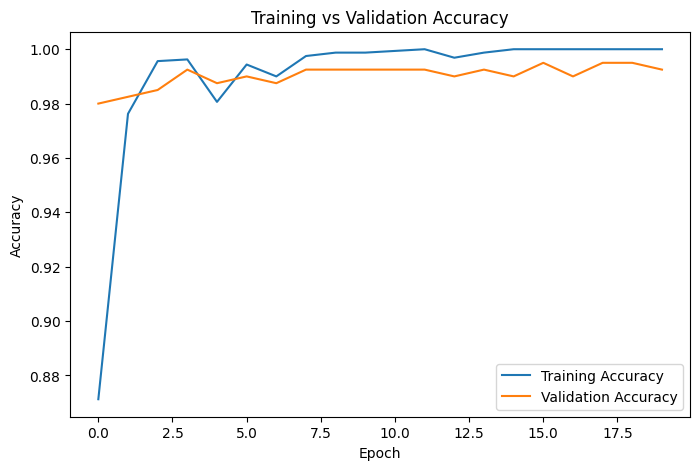

In [30]:
#For Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

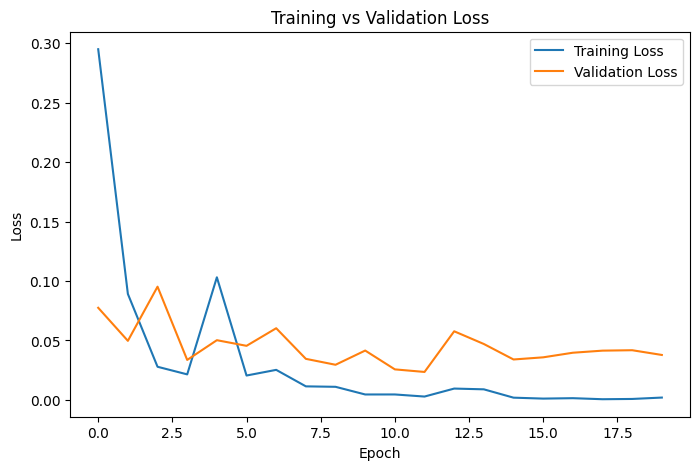

In [31]:
#For Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [35]:
import pandas as pd
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.871250,0.294934,0.9800,0.077491
1,0.976250,0.089130,0.9825,0.049689
2,0.995625,0.027883,0.9850,0.095235
3,0.996250,0.021478,0.9925,0.033628
4,0.980625,0.103119,0.9875,0.050231
5,0.994375,0.020512,0.9900,0.045492
6,0.990000,0.025280,0.9875,0.060284
7,0.997500,0.011405,0.9925,0.034539
8,0.998750,0.011025,0.9925,0.029562
9,0.998750,0.004579,0.9925,0.041515


Generating Predictions

In [36]:
import numpy as np

y_true = []
y_pred_prob = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Actual labels:", y_true[:20])
print("Predicted labels:", y_pred[:20])

Actual labels: [1. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1.]
Predicted labels: [1 1 0 1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 1]


Accuracy,precision,recall and f1_score

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9925
Precision: 0.9908675799086758
Recall   : 0.9954128440366973
F1 Score : 0.9931350114416476


In [39]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Gun", "No_Gun"]
))

              precision    recall  f1-score   support

         Gun       0.99      0.99      0.99       182
      No_Gun       0.99      1.00      0.99       218

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



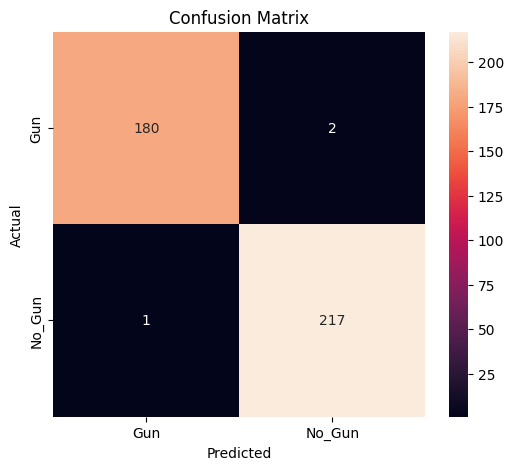

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Gun", "No_Gun"],
    yticklabels=["Gun", "No_Gun"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
#Testing Individual Images
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

def predict_image(image_path):
    image = load_img(image_path, target_size=(128, 128))
    image_array = img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    probability = model.predict(image_array, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = "No Gun"
        confidence = probability
    else:
        prediction = "Gun"
        confidence = 1 - probability

    print("Prediction:", prediction)
    print("Confidence:", f"{confidence * 100:.2f}%")

    plt.imshow(load_img(image_path))
    plt.title(f"{prediction} ({confidence * 100:.2f}%)")
    plt.axis("off")
    plt.show()

Prediction: No Gun
Confidence: 100.00%


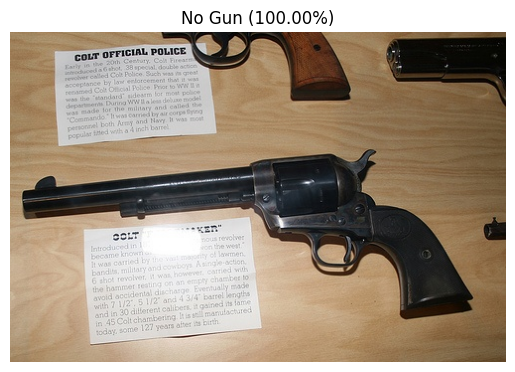

In [46]:
#For Gun Image
import os

gun_test_image = os.path.join(
    gun_path,
    os.listdir(gun_path)[8]
)

predict_image(gun_test_image)

Prediction: No Gun
Confidence: 100.00%


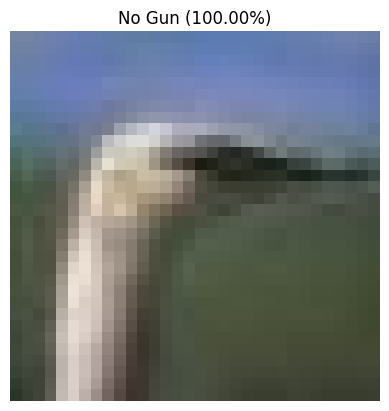

In [47]:
#No Gun
no_gun_test_image = os.path.join(
    no_gun_path,
    os.listdir(no_gun_path)[0]
)

predict_image(no_gun_test_image)

***Conclusion***

A CNN model was successfully developed to classify images as Gun or No Gun. The model achieved 99.25% validation accuracy, demonstrating effective image classification using TensorFlow/Keras.